<a href="https://colab.research.google.com/github/KinzaAsif2456/discoverey/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [1]:
#IMPORTS

import os
import json
import subprocess

import duckdb
from google.colab import userdata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

In [8]:

%pip install -q duckdb huggingface_hub
%pip install -q duckdb

In [3]:
# STEP 1 - Fetch data from starter repo
HF_TOKEN = userdata.get("HF_TOKEN")
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = "hf://datasets/FlyRank/internship-warehouse"
TABLES = {
    "dim_clients":      f"read_parquet('{REL}/dim_clients.parquet')",
    "dim_content":      f"read_parquet('{REL}/dim_content.parquet')",
    "fact_daily_march": f"read_parquet('{REL}/fact_content_daily_performance/month=2026-03/*.parquet')",
}
FEAT_START, FEAT_END, OUT_START = "2026-03-01", "2026-03-15", "2026-03-16"

In [4]:
# Features must come from the period BEFORE the outcome.


FEAT_START = "2026-03-01"
FEAT_END = "2026-03-15"
OUT_START = "2026-03-16"


print("Warehouse connection ready.")
print(f"Feature window: {FEAT_START} to {FEAT_END}")
print(f"Outcome starts: {OUT_START}")

Warehouse connection ready.
Feature window: 2026-03-01 to 2026-03-15
Outcome starts: 2026-03-16


In [5]:

#  Build page-level feature data


features = con.sql(
    f"""
    SELECT
        client_hash_id AS client_id,
        content_hash_id AS content_id,

        SUM(ga4_engaged_sessions)
            FILTER (WHERE ga4_data_available)
            AS ga4_engaged_sessions,

        SUM(ga4_sessions)
            FILTER (WHERE ga4_data_available)
            AS ga4_sessions,

        SUM(gsc_impressions) AS impressions,
        SUM(gsc_clicks) AS clicks,

        AVG(gsc_avg_position)
            FILTER (WHERE gsc_impressions > 0)
            AS avg_position

    FROM {TABLES['fact_daily_march']}

    WHERE report_date BETWEEN
        DATE '{FEAT_START}'
        AND DATE '{FEAT_END}'

    GROUP BY
        client_hash_id,
        content_hash_id

    HAVING SUM(gsc_impressions) >= 10
    """
).df()


# Calculate CTR after aggregation
features["ctr"] = (
    features["clicks"]
    / features["impressions"]
)


# STEP 2 — Build outcome data


outcome = con.sql(
    f"""
    SELECT
        client_hash_id AS client_id,
        content_hash_id AS content_id,

        SUM(gsc_impressions) AS outcome_impressions

    FROM {TABLES['fact_daily_march']}

    WHERE report_date >= DATE '{OUT_START}'

    GROUP BY
        client_hash_id,
        content_hash_id
    """
).df()


# STEP 3 — Merge features and outcome


df = features.merge(
    outcome,
    on=["client_id", "content_id"],
    how="left"
)


# Pages with no observed outcome traffic
# are treated as zero outcome impressions.
df["outcome_impressions"] = (
    df["outcome_impressions"]
    .fillna(0)
)


print("Feature rows:", len(features))
print("Outcome rows:", len(outcome))
print("Merged rows:", len(df))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Feature rows: 120513
Outcome rows: 331436
Merged rows: 120513


In [6]:
con.sql(f"DESCRIBE SELECT * FROM {TABLES['fact_daily_march']}").show()

┌────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│    column_name     │ column_type │  null   │   key   │ default │  extra  │
│      varchar       │   varchar   │ varchar │ varchar │ varchar │ varchar │
├────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ report_date        │ DATE        │ YES     │ NULL    │ NULL    │ NULL    │
│ client_hash_id     │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ content_hash_id    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ client_has_gsc     │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ client_has_ga4     │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ gsc_data_available │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ ga4_data_available │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ gsc_impressions    │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ gsc_clicks         │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │

In [7]:

# STEP 4 — Merge feature + outcome data


df = features.merge(
    outcome,
    on=["client_id", "content_id"],
    how="left"
)

df["impressions_outcome"] = (
    df["impressions_outcome"].fillna(0)
)

KeyError: 'impressions_outcome'

In [ ]:
# Step 1 — Get the Dataset

STARTER_REPO = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
if not os.path.isdir("flyrank-ml-internship-starter"):
    subprocess.run(["git", "clone", "--depth", "1", STARTER_REPO, "flyrank-ml-internship-starter"], check=True)


df = pd.read_csv("flyrank-ml-internship-starter/data/raw/content_refresh_anonymized.csv")


In [ ]:
# Step 2 —  Basic dataset checks
print(f"Dataset shape: {df.shape}")
print(f"Duplicate content_ids: {df['content_id'].duplicated().sum()}")
print(f"Overall decline rate: {df['trend_direction'].eq('down').mean():.3f}")
print("duplicate content_id rows:", df["content_id"].duplicated().sum())

Dataset shape: (30000, 44)
Duplicate content_ids: 0
Overall decline rate: 0.542
duplicate content_id rows: 0


In [ ]:
# --- Recreate label + rule flags (same logic as w04/w05, unchanged) ---
df["is_declining_label"] = (df["trend_direction"] == "down").astype(int)

STALE_TIERS = ["91-180", "181+"]
CTR_THRESHOLD = 0.005
IMPRESSION_DECOY_LEVEL = 5000

df["stale_flag"] = df["freshness_tier"].isin(STALE_TIERS)
df["low_ctr_flag"] = (df["avg_position"] <= 20) & (df["ctr"] < CTR_THRESHOLD) & (df["impressions_90d"] >= 500)
df["is_decoy"] = (df["freshness_tier"] == "181+") & (df["impressions_90d"] >= IMPRESSION_DECOY_LEVEL)

# Features from Week 6
tier_order = ["0-30", "31-90", "91-180", "181+"]
df["freshness_tier_enc"] = df["freshness_tier"].map({t: i for i, t in enumerate(tier_order)})
df["avg_position_missing"] = (df["avg_position"] == 0).astype(int)

FEATURES = ["freshness_tier_enc", "avg_position", "ctr", "impressions_90d", "avg_position_missing"]

# Train the final RF model
# Note: this is different from w06's CV loop on purpose. w06 held out folds to
# measure honest performance (0.872 ± 0.069). This fit uses all rows because
# we're generating an practical queue, not a validation number — the 0.872
# figure from w06 is what we cite as the expected precision, not re-measured here.
rf = RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=5,
                             random_state=42, n_jobs=-1)
rf.fit(df[FEATURES], df["is_declining_label"])

# In-sample RF score used only to rank the working queue.
# The validated performance figure comes from grouped CV in w06.
df["model_score"] = rf.predict_proba(df[FEATURES])[:, 1]

#  Keep top-ranked pages
queue_size = 200  # bigger than the P@50 metric window — this is a real backlog, not just the top 50
queue_df = df.sort_values(["model_score", "impressions_90d"], ascending=[False, False]).head(queue_size).copy()

# Assign a reason to each page
def reason_code(row):
    if row["is_decoy"]:
        return "high_traffic_stale"
    if row["stale_flag"] and row["low_ctr_flag"]:
        return "stale_and_underperforming"
    if row["avg_position_missing"]:
        return "unranked"
    if row["stale_flag"]:
        return "stale"
    if row["low_ctr_flag"]:
        return "low_ctr"
    return "model_signal_only"  # least explainable — flag for extra review in Section 3

queue_df["reason_code"] = queue_df.apply(reason_code, axis=1)
print(queue_df["reason_code"].value_counts())

reason_code
stale                        148
stale_and_underperforming     49
model_signal_only              3
Name: count, dtype: int64


In [ ]:
counts = queue_df["reason_code"].value_counts()

print("\nReason code distribution:")
for reason, count in counts.items():
    print(f"{reason}: {count}")


Reason code distribution:
stale: 148
stale_and_underperforming: 49
model_signal_only: 3


In [ ]:
top_reason = counts.index[0]
top_count = counts.iloc[0]
top_percent = top_count / len(queue_df) * 100

print(
    f"\nMost common reason code: {top_reason} "
    f"({top_count} pages, {top_percent:.1f}% of the queue)"
)


Most common reason code: stale (148 pages, 74.0% of the queue)


#### Decay and refresh insight

After checking the reason-code distribution, I found that most pages belong to the `stale` category. This shows that page age plays a major role in deciding which pages appear in the action queue. The remaining categories point to different types of problems, so they should not all be handled in the same way.

Instead of giving every page the same recommendation, I would use the reason codes to decide what kind of review is needed.

- **`stale`** – Add these pages to the regular content refresh schedule.
- **`stale_and_underperforming` and `low_ctr`** – Review the title and meta description first because these are usually quicker fixes.
- **`unranked`** – Check indexing or other technical issues before editing the content.
- **`high_traffic_stale`** – Review these pages earlier since they already receive a good amount of traffic.
- **`model_signal_only`** – These pages should always be checked manually because there is no clear rule explaining the prediction.

In [ ]:
#  Suggested action for each reason
# EDIT THIS DICT YOURSELF — the mapping is your judgment call, not the model's.
# Format: archetype -> recommended action
action_map = {
    "stale_and_underperforming": "Rewrite title + meta description (cheap, fast)",
    "high_traffic_stale": "Priority full refresh — traffic at risk",
    "unranked": "Check indexing/technical issues before content work",
    "stale": "Schedule for content refresh",
    "low_ctr": "Review title/meta for click appeal",
    "model_signal_only": "Manual review — no clear rule reason, verify before acting",
}
queue_df["recommended_action"] = queue_df["reason_code"].map(action_map)

### Reason codes & queue analysis

I assigned reason codes using the rule-based checks created earlier in the notebook instead of relying only on the model score. This makes it easier to understand why a page appears in the queue and helps explain each recommendation.

#### Reason codes

* **`high_traffic_stale`** – Pages in the oldest freshness group with at least 5,000 impressions over the last 90 days. These are reviewed first because they already receive substantial traffic.
* **`stale_and_underperforming`** – Older pages that also have a low CTR while still ranking within the top 20 positions. A title or metadata update is a reasonable first step.
* **`unranked`** – Pages where the average position is recorded as 0. These should be checked for indexing or technical issues before making content changes.
* **`stale`** – Older pages that meet the freshness condition but do not trigger any additional priority rules.
* **`low_ctr`** – Pages with enough impressions and a good ranking position but a weak CTR. Improving titles or meta descriptions may help.
* **`model_signal_only`** – Pages selected by the model without matching any rule-based condition. These need manual review before taking action.

#### Archetype → action mapping

The recommended actions are meant to give editors a practical starting point. They are suggestions only and are not intended to automate any content changes.

- **high_traffic_stale** → Priority full refresh: Old pages with significant traffic (
5,000 impressions) have meaningful existing traffic and therefore deserve earlier review.
- **stale_and_underperforming** → Rewrite title & meta description: A cheap, fast first step to recover weak CTR on aging pages before committing to a full rewrite.
- **unranked** → Check technical indexing: Investigate Search Console and index status before wasting editorial time updating copy.
- **stale** → Schedule for routine refresh: Add to the standard content maintenance backlog; age is the only trigger, so no urgent intervention is required.
- **low_ctr** → Optimize metadata: Strong average positions with poor CTR indicate a snippet/title problem, making metadata tweaks a reasonable low-cost first step.
- **model_signal_only** → Manual review: Requires human judgment to identify silent decline factors since no explicit rule flags were triggered.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [ ]:
print(f"Dataset: {df.shape[0]} rows, {df['client_id'].nunique()} clients, single snapshot")
print(f"Model P@50 (honest, grouped CV, from w06): 0.872 ± 0.069")
print(f"Baseline P@50 (rule-based, grouped CV):     0.788 ± 0.124")

Dataset: 30000 rows, 32 clients, single snapshot
Model P@50 (honest, grouped CV, from w06): 0.872 ± 0.069
Baseline P@50 (rule-based, grouped CV):     0.788 ± 0.124


### Intended use and limitations

I built this model to help sort pages that may need attention. The ranking should be treated as a starting point for editors instead of a final decision. Every recommendation still needs someone to review it before making changes.

There are also a few limitations worth keeping in mind.

- The model was trained using one snapshot of the dataset, so I haven't checked how well it performs on future data.

- The pages are spread across only 32 clients, and some clients contribute many more pages than others. Because of that, the grouped cross-validation scores are not exactly the same in every fold.

- I also haven't tested the model on completely new clients. Before using it on unseen data, I would want to validate that it performs similarly.

In [ ]:
top_reason = counts.index[0]
top_count = counts.iloc[0]
top_percent = top_count / len(queue_df) * 100

print(
    f"\nMost common reason code: {top_reason} "
    f"({top_count} pages, {top_percent:.1f}% of the queue)"
)


Most common reason code: stale (148 pages, 74.0% of the queue)


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [ ]:
# Flag rows needing mandatory review before any action

needs_review = queue_df[
    (queue_df["reason_code"] == "model_signal_only") |
    (queue_df["model_score"] < queue_df["model_score"].quantile(0.6))
].copy()

num_review = len(needs_review)
total_queue = len(queue_df)
review_percent = num_review / total_queue * 100

print(
    f"{num_review} of {total_queue} queue rows "
    f"flagged for mandatory review ({review_percent:.1f}%)"
)

120 of 200 queue rows flagged for mandatory review (60.0%)


### Human review and guardrails


Of the top 200 queue recommendations, **120 pages (60%) require mandatory human review** before taking action.

Review triggers are split into two categories:
* **`model_signal_only` cases:** Pages flagged by the model without clear rule-based triggers.
* **Marginal-confidence scores:** Pages sitting near the lower score threshold of the top-200 queue.

> **Key takeaway:** These guardrails ensure the model operates strictly as a decision-support ranking tool. Automated script execution across these flagged rows is prohibited—final actions require explicit editorial sign-off.


#### Cost/value logic & prioritization strategy

Because editorial review time is finite, the queue prioritizes low-cost, high-impact changes before escalating to expensive content rewrites.

* **`high_traffic_stale` → Priority refresh:** Since these pages already attract a large number of visitors, reviewing them earlier may help prevent future traffic loss.

* **`stale_and_underperforming` → Update title and meta description:** I would begin with smaller metadata improvements before considering a complete rewrite.

* **`unranked` → Check indexing first:** Technical issues should be ruled out before spending time updating page content.

* **`stale` → Regular content refresh:** These pages can be added to the normal content maintenance schedule because age is the main concern.

* **`low_ctr` → Improve metadata:** A low CTR with a reasonable ranking position often points to a title or meta description that could be improved.

* **`model_signal_only` → Manual review:** Since there is no matching rule-based explanation, an editor should review these pages before making any decision.

> **Note:** The model ranks relative decline risk, not direct dollar impact. This cost/value framework functions as an operational effort filter, not a financial revenue forecast.


#### Things I would not automate

Some actions should always stay under human control, even if the model assigns a high score.

- I would not let the model publish or rewrite content automatically. Editors should approve every change.

- A high model score alone isn't enough to remove or de-index a page. Business context and technical checks still matter.

- These predictions should never be used to judge writers or editorial staff because the model only looks at page-level signals.

- I also wouldn't apply the same update across the whole queue. It's safer to review a sample first before making large-scale changes.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [ ]:
metrics_ref = {
    "model_precision_at_50_grouped": {"mean": 0.872, "std": 0.069},
    "baseline_precision_at_50_grouped": {"mean": 0.788, "std": 0.124},
    "n_clients_at_training": int(df["client_id"].nunique()),
}

### Monitoring and retraining

The current model works well on the available data, but I wouldn't assume it will stay that way forever. I would check the model again whenever one of these situations occurs.

- Precision@50 falls below the rule-based baseline of 0.788.

- The grouped validation scores become much less consistent across clients than they are now.

- New client data is added, since the model hasn't been tested on unseen clients.

- A few months have passed since training. Because this model comes from one snapshot of the data, periodic checks are a good idea.

Retraining alone wouldn't be enough to replace the current model. I'd first run the same grouped cross-validation process again and only switch models if the new one performs at least as well.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [ ]:
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

#  Save queue (work/**/*.csv), notebook regenerates it
export_cols = ["content_id", "client_id", "reason_code", "recommended_action",
               "model_score", "freshness_tier", "avg_position", "ctr", "impressions_90d"]
queue_df[export_cols].to_csv("work/outputs/ranked_action_queue.csv", index=False)

# Save summary metrics — this one DOES get committed (not a CSV, not gitignored)
metrics = {
    **metrics_ref,
    "queue_size": queue_size,
    "reason_code_counts": queue_df["reason_code"].value_counts().to_dict(),
}
with open("work/outputs/playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Exported queue + metrics")

Exported queue + metrics


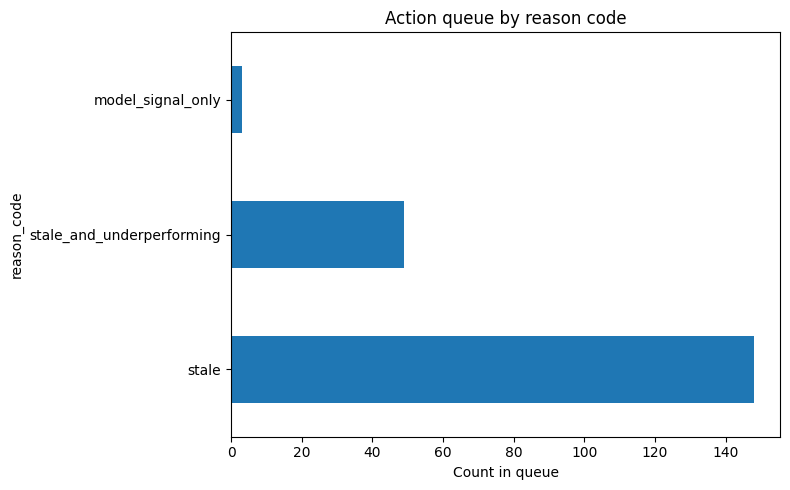

In [ ]:


#  Plot reason counts
fig, ax = plt.subplots(figsize=(8, 5))
queue_df["reason_code"].value_counts().plot(kind="barh", ax=ax)
ax.set_xlabel("Count in queue")
ax.set_title("Action queue by reason code")
plt.tight_layout()
plt.savefig("work/figures/reason_code_distribution.png", dpi=150)
plt.show()

In [ ]:
print("ML-10 self-check")
print("----------------")

checks = {
    "Queue has 200 rows": len(queue_df) == queue_size,
    "Reason codes created": queue_df["reason_code"].notna().all(),
    "Recommended actions created": queue_df["recommended_action"].notna().all(),
    "Review set created": len(needs_review) >= 0,
    "Queue CSV exists": os.path.exists("work/outputs/ranked_action_queue.csv"),
    "Metrics JSON exists": os.path.exists("work/outputs/playbook_metrics.json"),
    "Figure exists": os.path.exists("work/figures/reason_code_distribution.png"),
}

for check, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'}: {check}")

print(f"\nQueue rows: {len(queue_df)}")
print(f"Clients: {df['client_id'].nunique()}")
print(f"Reason codes used: {queue_df['reason_code'].nunique()}")
print(f"Mandatory review rows: {len(needs_review)}")

ML-10 self-check
----------------
PASS: Queue has 200 rows
PASS: Reason codes created
PASS: Recommended actions created
PASS: Review set created
PASS: Queue CSV exists
PASS: Metrics JSON exists
PASS: Figure exists

Queue rows: 200
Clients: 32
Reason codes used: 3
Mandatory review rows: 120


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.